In [52]:
import sqlite3
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

Within the analysis of this dataset, I aimed to answer several questions including: 
- Sales Trends: How does total revenue trend month-over-month? 
- Delivery Performance: What percentage of orders arrive after the estimated delivery date?
- Customer Location: Which Brazilian states generate the highest volume of sales?
- Payment Choice: Do customers spending more money use more installment payments?
- Review Triggers: How strongly do delivery delays correlate with 1-star review scores?

# Sales Trends

How does total revenue trend month-over-month? 

In [53]:
query: str = """
SELECT
op.payment_value,
strftime('%m', oi.order_purchase_timestamp) AS order_month
FROM 'order payments' AS op
INNER JOIN 'orders' AS oi ON op.order_id = oi.order_id
GROUP BY order_month
ORDER BY op.payment_value DESC

            """
conn: sqlite3.Connection = sqlite3.connect("../database/olist.db")
df: pd.DataFrame = pd.read_sql(query, conn)

df

,payment_value,order_month
0,341.09,07
1,244.15,01
2,188.73,11
3,157.45,03
4,128.45,05
5,102.66,08
6,99.33,04
7,89.68,02
8,65.71,12
9,47.69,09


C:\Users\emera\AppData\Local\Temp\ipykernel_45172\1642701300.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["order_month"], y=df["payment_value"], palette="deep")


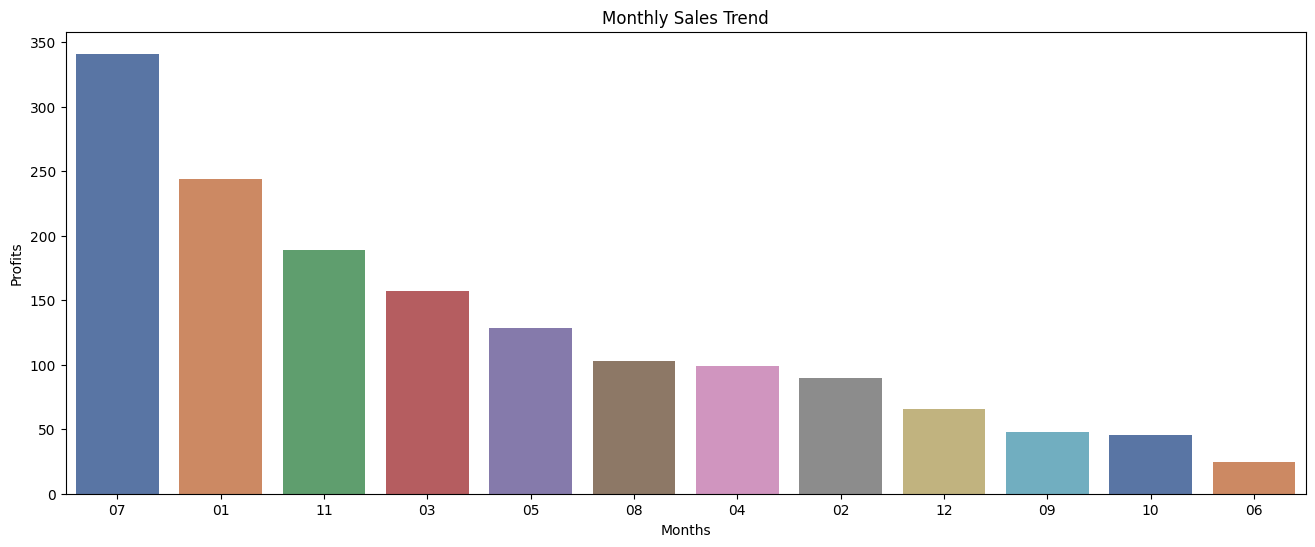

In [54]:
plt.figure(figsize=(16,6))
sns.barplot(x=df["order_month"], y=df["payment_value"], palette="deep")
plt.title("Monthly Sales Trend")
plt.xlabel("Months")
plt.ylabel("Profits")
plt.show()

# Delivery Performance

What percentage of orders arrive after the estimated delivery date?

In [86]:
query = """
        SELECT
        strftime('%Y', order_purchase_timestamp) AS order_year,
        strftime('%m', order_purchase_timestamp) AS order_month,
        julianday(order_estimated_delivery_date) - julianday(order_delivered_customer_date) AS date_diff
        FROM orders
        WHERE order_status = 'delivered' 
        GROUP BY order_year, order_month
        """

df: pd.DataFrame = pd.read_sql(query, conn)

df  

,order_year,order_month,date_diff
0,2016,09,-36.324745
1,2016,10,51.391667
2,2016,12,21.336991
3,2017,01,31.410995
4,2017,02,11.397245
5,2017,03,-7.567546
6,2017,04,1.612558
7,2017,05,11.461215
8,2017,06,16.214259
9,2017,07,5.543113


In [91]:
late = (df["date_diff"] > 0).sum()
total = df["date_diff"].count()

percent_late = late / total * 100
percent_late


print(f"The percentage of late orders is roughly: {percent_late:.2f}%")

The percentage of late orders is roughly: 86.96%


# Customer Location

Most profitable city

In [ ]:
query: str = """
SELECT customer_city, customer_state, COUNT(*) AS CustomerCount
FROM customers
GROUP BY customer_city
HAVING COUNT(*) > 300
ORDER BY COUNT(*) DESC
"""
conn: sqlite3.Connection = sqlite3.connect("../database/olist.db")
df: pd.DataFrame = pd.read_sql(query, conn)

#Only considering cities with 300+ customer
df

,customer_city,customer_state,CustomerCount
0,sao paulo,SP,15540
1,rio de janeiro,RJ,6882
2,belo horizonte,MG,2773
3,brasilia,DF,2131
4,curitiba,PR,1521
5,campinas,SP,1444
6,porto alegre,RS,1379
7,salvador,BA,1245
8,guarulhos,SP,1189
9,sao bernardo do campo,SP,938


C:\Users\emera\AppData\Local\Temp\ipykernel_45172\3134588382.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["customer_city"], y=df["CustomerCount"], palette="bright")


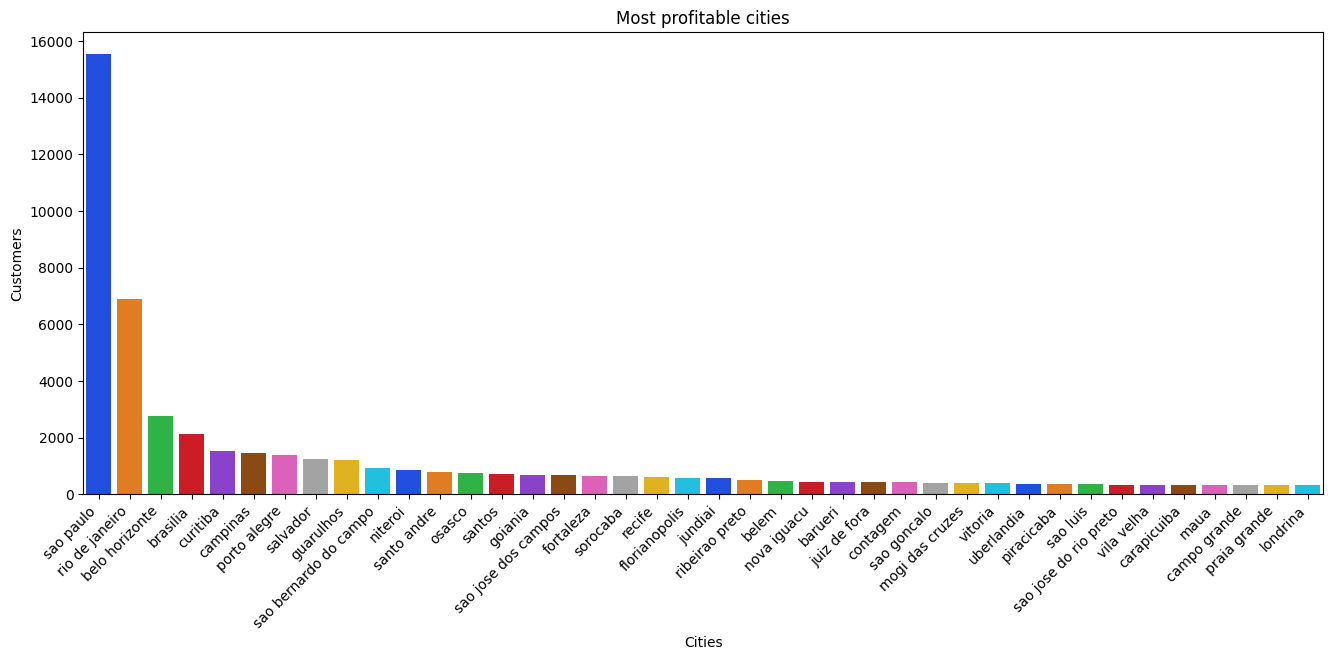

In [ ]:
plt.figure(figsize=(16,6))
sns.barplot(x=df["customer_city"], y=df["CustomerCount"], palette="bright")
plt.title("Most profitable cities")
plt.xlabel("Cities")
plt.ylabel("Customers")
plt.xticks(rotation=45, ha="right")
plt.show()

Most profitable states

In [ ]:
query: str = """
SELECT customer_state, COUNT(*) AS CustomerCount
FROM customers 
GROUP BY customer_state
ORDER BY COUNT(*) DESC
"""
conn: sqlite3.Connection = sqlite3.connect("../database/olist.db")
df: pd.DataFrame = pd.read_sql(query, conn)

df

,customer_state,CustomerCount
0,SP,41746
1,RJ,12852
2,MG,11635
3,RS,5466
4,PR,5045
5,SC,3637
6,BA,3380
7,DF,2140
8,ES,2033
9,GO,2020


C:\Users\emera\AppData\Local\Temp\ipykernel_45172\1788467792.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df["customer_state"], y=df["CustomerCount"], palette="pastel")


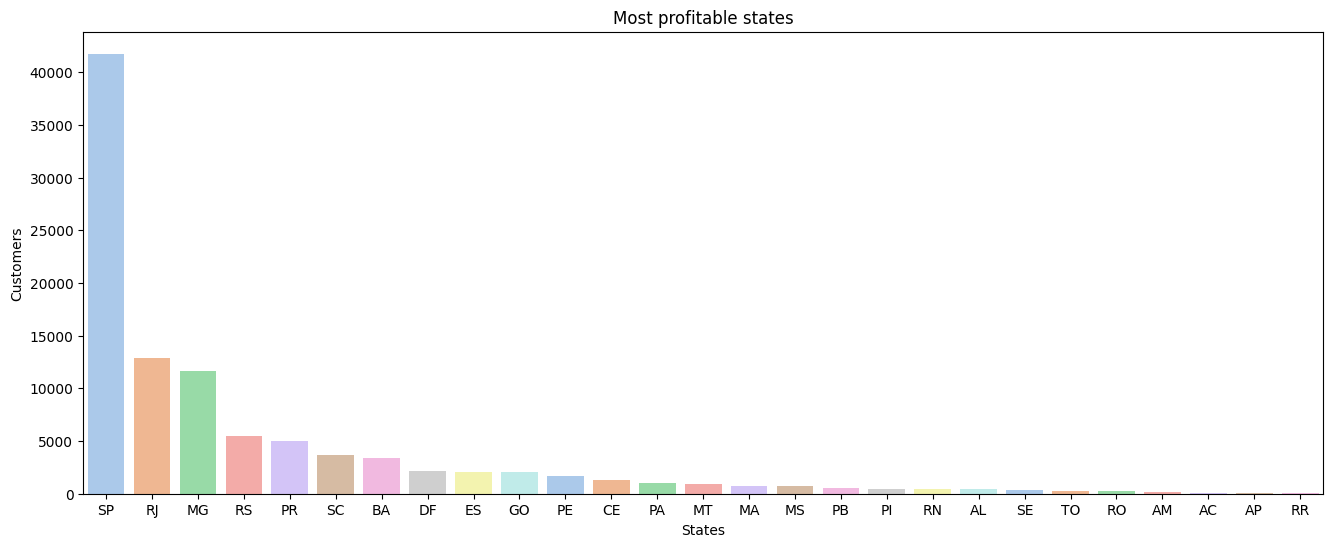

In [ ]:
#Better to generate a graph of states since there are so many more cities
plt.figure(figsize=(16,6))
sns.barplot(x=df["customer_state"], y=df["CustomerCount"], palette="pastel")
plt.title("Most profitable states")
plt.xlabel("States")
plt.ylabel("Customers")
plt.show()

# Payment Choice
- Payment Choice: Do customers spending more money use more installment payments?

In [ ]:
query: str = """
SELECT
c.customer_id,
SUM(op.payment_installments) AS total_installations, 
SUM(op.payment_value) AS total_spendings
FROM 'order payments' AS op
INNER JOIN orders AS o ON op.order_id = o.order_id
INNER JOIN customers AS c ON c.customer_id = o.customer_id
GROUP BY c.customer_id
ORDER BY total_spendings DESC
"""
conn: sqlite3.Connection = sqlite3.connect("../database/olist.db")
df: pd.DataFrame = pd.read_sql(query, conn)

df

,customer_id,total_installations,total_spendings
0,1617b1357756262bfa56ab541c47bc16,1,13664.08
1,ec5b2ba62e574342386871631fafd3fc,1,7274.88
2,c6e2731c5b391845f6800c97401a43a9,8,6929.31
3,f48d464a0baaea338cb25f816991ab1f,1,6922.21
4,3fd6777bbce08a352fddd04e4a7cc8f6,1,6726.66
...,...,...,...
99435,184e8e8e48937145eb96c721ef1f0747,1,10.07
99436,a790343ca6f3fee08112d678b43aa7c5,2,9.59
99437,a73c1f73f5772cf801434bf984b0b1a7,1,0.00
99438,3532ba38a3fd242259a514ac2b6ae6b6,1,0.00


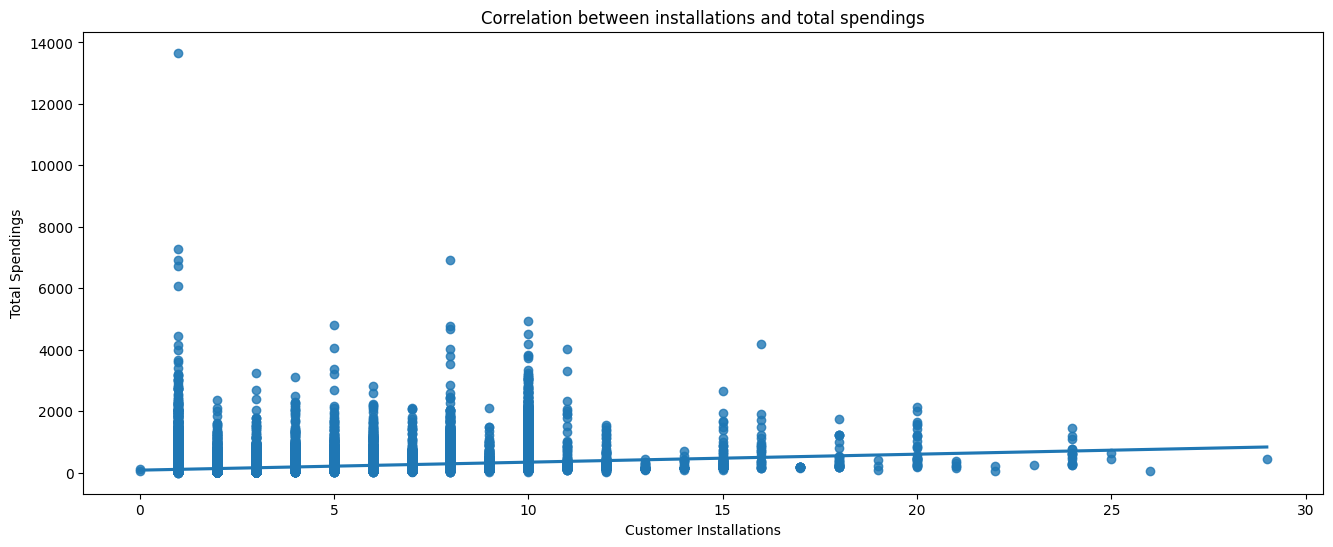

In [ ]:
plt.figure(figsize=(16,6))

sns.regplot(x=df["total_installations"], y=df["total_spendings"])
plt.title("Correlation between installations and total spendings")
plt.xlabel("Customer Installations")
plt.ylabel("Total Spendings")
plt.show()

# Review Triggers


How strongly do delivery delays correlate with 1-star review scores?

In [ ]:
query: str = """
SELECT
o.order_id,
ore.review_score,
julianday(o.order_delivered_customer_date) - julianday(o.order_estimated_delivery_date) AS delivery_lateness
FROM orders AS o
INNER JOIN "order reviews" AS ore 
ON o.order_id = ore.order_id
WHERE o.order_delivered_customer_date IS NOT NULL 
AND o.order_estimated_delivery_date IS NOT NULL
GROUP BY o.order_id 
ORDER BY ore.review_score ASC
"""
conn: sqlite3.Connection = sqlite3.connect("../database/olist.db")
df: pd.DataFrame = pd.read_sql(query, conn)

df

,order_id,review_score,delivery_lateness
0,0005a1a1728c9d785b8e2b08b904576c,1,0.762164
1,000aed2e25dbad2f9ddb70584c5a2ded,1,-3.301030
2,00169e31ef4b29deaae414f9a5e95929,1,-14.153426
3,0017afd5076e074a48f1f1a4c7bac9c5,1,4.355637
4,001d8f0e34a38c37f7dba2a37d4eba8b,1,2.551968
...,...,...,...
95825,fffc94f6ce00a00581880bf54a75a037,5,-7.043981
95826,fffcd46ef2263f404302a634eb57f7eb,5,-8.144502
95827,fffce4705a9662cd70adb13d4a31832d,5,-12.484468
95828,fffe18544ffabc95dfada21779c9644f,5,-8.083565


(0.5, 5.5)

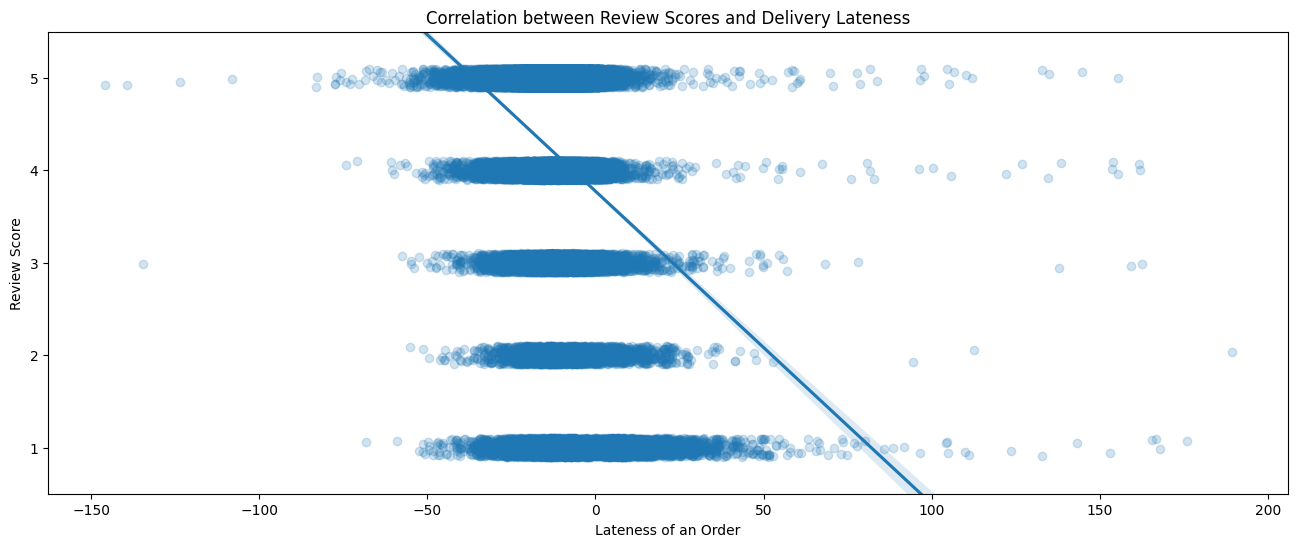

In [ ]:
plt.figure(figsize=(16,6))
sns.regplot(x=df["delivery_lateness"], 
            y=df["review_score"],
            x_jitter=0.3,
            y_jitter=0.1,
            scatter_kws={"alpha":0.2}
            )
plt.title("Correlation between Review Scores and Delivery Lateness")
plt.xlabel("Lateness of an Order")
plt.ylabel("Review Score")
plt.ylim(0.5, 5.5)
#Clearly, the orders that are delivered later lead to worse reviews

# Bonus: Most purchases dates

In [ ]:
query: str = """
SELECT DATE(order_purchase_timestamp) AS purchase_date,
       COUNT(*) AS order_count
FROM orders
GROUP BY DATE(order_purchase_timestamp)
ORDER BY COUNT(*) DESC;

"""
conn: sqlite3.Connection = sqlite3.connect("../database/olist.db")
df: pd.DataFrame = pd.read_sql(query, conn)

df

,purchase_date,order_count
0,2017-11-24,1176
1,2017-11-25,499
2,2017-11-27,403
3,2017-11-26,391
4,2017-11-28,380
...,...,...
629,2016-10-02,1
630,2016-09-15,1
631,2016-09-13,1
632,2016-09-05,1


99441 orders

# Bonus: Most common delivery dates

In [ ]:
query = """
        SELECT DATE(order_delivered_customer_date),
        COUNT(*)
        FROM orders
        GROUP BY DATE(order_delivered_customer_date)
        ORDER BY COUNT(*) DESC
        """

df: pd.DataFrame = pd.read_sql(query, conn)
df

,DATE(order_delivered_customer_date),COUNT(*)
0,NaN,2965
1,2018-08-27,446
2,2018-08-13,442
3,2018-05-14,434
4,2018-05-21,431
...,...,...
641,2016-11-21,1
642,2016-11-14,1
643,2016-11-05,1
644,2016-10-30,1


# Bonus: Most popular categories

In [ ]:
query = """
        SELECT t.product_category_name_english,
        COUNT(*) AS count_orders
        FROM products AS p
        INNER JOIN 'order items' AS oi ON p.product_id = oi.product_id
        INNER JOIN 'product category name translation' AS t ON p.product_category_name = t.product_category_name
        GROUP BY t.product_category_name_english
        ORDER BY COUNT(*) DESC
        """

df: pd.DataFrame = pd.read_sql(query, conn)
df

,product_category_name_english,count_orders
0,bed_bath_table,11115
1,health_beauty,9670
2,sports_leisure,8641
3,furniture_decor,8334
4,computers_accessories,7827
...,...,...
66,arts_and_craftmanship,24
67,la_cuisine,14
68,cds_dvds_musicals,14
69,fashion_childrens_clothes,8


In [ ]:
def read_SQL_Query(filePath) -> pd.DataFrame:
    with open(Path(filePath), "r") as file:
        query: str = file.read()

    df: pd.DataFrame = pd.read_sql(query, conn)
    return df

customer_count: pd.DataFrame = read_SQL_Query(r"..\sql\test.sql")
customer_count

,customer_city,customer_state,CustomerCount
0,sao paulo,SP,15540
1,rio de janeiro,RJ,6882
2,belo horizonte,MG,2773
3,brasilia,DF,2131
4,curitiba,PR,1521
...,...,...,...
4305,vitoria do jari,AP,1
4306,vitorino,PR,1
4307,vitorinos,MG,1
4308,wagner,BA,1
